In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, balanced_accuracy_score, classification_report
from sklearn.datasets import load_breast_cancer

import warnings
warnings.filterwarnings("ignore")

In [2]:
feature_space = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity']

In [3]:
data = load_breast_cancer()

df_og = pd.DataFrame(data.data, columns=data.feature_names)
df_og['target'] = data.target

df_og.sample(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
387,13.88,16.16,88.37,596.6,0.07026,0.04831,0.02045,0.008507,0.1607,0.05474,...,19.97,99.66,745.3,0.08484,0.1233,0.1091,0.04537,0.2542,0.06623,1


In [4]:
df_og.value_counts('target')

target
1    357
0    212
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_og, test_size=0.3, random_state=0, stratify=df_og['target'])

X_test = test[feature_space]
y_test = test['target']

In [6]:
df_majority = train[train['target'] == 1]
df_minority = train[train['target'] == 0]

df_minority_undersampled = df_minority.sample(n=5, random_state=1)

df = pd.concat([df_majority, df_minority_undersampled])
df = df.sample(frac=1, random_state=1).reset_index(drop=True)

print('train df contains {} samples with target 0 and {} samples with target 1'.format(df['target'].value_counts()[0], df['target'].value_counts()[1]))

train df contains 5 samples with target 0 and 250 samples with target 1


In [7]:
import xgboost as xgb

X_train = df[feature_space]
y_train = df['target']

model = xgb.XGBClassifier(random_state=0)
model.fit(X_train, y_train)

y_preds = model.predict(X_test)

balanced_acc = balanced_accuracy_score(y_test, y_preds)
print("Balanced accuracy:", balanced_acc)

print(classification_report(y_test, y_preds, target_names=['Class 0','Class 1']))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_preds))


Balanced accuracy: 0.6703417056074766
              precision    recall  f1-score   support

     Class 0       0.92      0.36      0.52        64
     Class 1       0.72      0.98      0.83       107

    accuracy                           0.75       171
   macro avg       0.82      0.67      0.67       171
weighted avg       0.79      0.75      0.71       171

Balanced accuracy: 0.6703417056074766


In [8]:
df_base = df_minority_undersampled

In [9]:
from sdv.single_table import GaussianCopulaSynthesizer, CTGANSynthesizer
from sdv.metadata import Metadata
from imblearn.over_sampling import SMOTE, ADASYN, SVMSMOTE, KMeansSMOTE, RandomOverSampler

In [10]:
def generate_minority_df(df_majority, df_minority, ratio: int, synthesizer: str):
    n_majority = len(df_majority)
    desired_minority_total = n_majority // ratio
    n_to_generate = max(desired_minority_total - len(df_minority), 0)
    df_synth = pd.DataFrame()
    
    if n_to_generate == 0:
        return pd.concat([df_majority, df_minority]).reset_index(drop=True)
    
    if synthesizer == 'gaussian':
    
        metadata = Metadata.detect_from_dataframe(data=df_minority)
        gc = GaussianCopulaSynthesizer(metadata)
        gc.fit(df_minority)
        df_synth = gc.sample(n_to_generate)

    elif synthesizer == 'ctgan':

        metadata = Metadata.detect_from_dataframe(data=df_minority)
        ctgan = CTGANSynthesizer(metadata, cuda=False)
        ctgan.fit(df_minority)
        df_synth = ctgan.sample(n_to_generate)

    elif synthesizer == 'smote':

        smote = SMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'adasyn':

        adasyn = ADASYN(sampling_strategy=1/ratio, random_state=0, n_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = adasyn.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'svm_smote':

        svm_smote = SVMSMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = svm_smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'kmeans_smote':

        kmeans_smote = KMeansSMOTE(sampling_strategy=1/ratio, random_state=0, k_neighbors=4)
        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']
        X_train_sm, y_train_sm = kmeans_smote.fit_resample(X_tmp, y_tmp)
        tmp = pd.concat([X_train_sm, y_train_sm], axis=1).reset_index(drop=True)
        
        return tmp[feature_space], tmp['target']
    
    elif synthesizer == 'random_oversample':

        tmp = pd.concat([df_majority, df_minority]).reset_index(drop=True)
        X_tmp = tmp[feature_space]
        y_tmp = tmp['target']

        ros = RandomOverSampler(
            sampling_strategy={0: desired_minority_total},
            random_state=0
        )

        X_res, y_res = ros.fit_resample(X_tmp, y_tmp)
        tmp_res = pd.concat([X_res, y_res], axis=1).reset_index(drop=True)

        return tmp_res[feature_space], tmp_res['target']

    df_minority_expanded = pd.concat([df_minority, df_synth]).reset_index(drop=True)
    df_combined = pd.concat([df_majority, df_minority_expanded]).reset_index(drop=True)
    
    return df_combined[feature_space], df_combined['target']

In [11]:
X_dfGaussian25, y_dfGaussian25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='gaussian')
X_dfGaussian10, y_dfGaussian10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='gaussian')
X_dfGaussian5, y_dfGaussian5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='gaussian')  
X_dfGaussian2, y_dfGaussian2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='gaussian')
X_dfGaussian1, y_dfGaussian1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='gaussian')

In [12]:
len(X_dfGaussian25)

260

In [13]:
X_dfCTGAN25, y_dfCTGAN25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='ctgan')
X_dfCTGAN10, y_dfCTGAN10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='ctgan')
X_dfCTGAN5, y_dfCTGAN5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='ctgan')
X_dfCTGAN2, y_dfCTGAN2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='ctgan')
X_dfCTGAN1, y_dfCTGAN1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='ctgan')

In [14]:
X_dfSMOTE25, y_dfSMOTE25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='smote')
X_dfSMOTE10, y_dfSMOTE10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='smote')
X_dfSMOTE5, y_dfSMOTE5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='smote')  
X_dfSMOTE2, y_dfSMOTE2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='smote')  
X_dfSMOTE1, y_dfSMOTE1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='smote')     

In [15]:
X_dfADASYN25, y_dfADASYN25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='adasyn')
X_dfADASYN10, y_dfADASYN10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='adasyn')
X_dfADASYN5, y_dfADASYN5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='adasyn')
X_dfADASYN2, y_dfADASYN2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='adasyn')
X_dfADASYN1, y_dfADASYN1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='adasyn')

In [16]:
X_dfRandom25, y_dfRandom25 = generate_minority_df(df_majority, df_minority_undersampled, ratio=25, synthesizer='random_oversample')
X_dfRandom10, y_dfRandom10 = generate_minority_df(df_majority, df_minority_undersampled, ratio=10, synthesizer='random_oversample')
X_dfRandom5, y_dfRandom5 = generate_minority_df(df_majority, df_minority_undersampled, ratio=5, synthesizer='random_oversample')
X_dfRandom2, y_dfRandom2 = generate_minority_df(df_majority, df_minority_undersampled, ratio=2, synthesizer='random_oversample')
X_dfRandom1, y_dfRandom1 = generate_minority_df(df_majority, df_minority_undersampled, ratio=1, synthesizer='random_oversample')

In [17]:
print(y_dfGaussian2.value_counts('target'), y_dfCTGAN2.value_counts('target'), y_dfSMOTE2.value_counts('target')
, y_dfADASYN2.value_counts('target'), y_dfRandom2.value_counts('target'))
print(len(y_dfGaussian2), len(y_dfCTGAN2), len(y_dfSMOTE2), len(y_dfADASYN2), len(y_dfRandom2))

target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64 target
1    0.664894
0    0.335106
Name: proportion, dtype: float64 target
1    0.666667
0    0.333333
Name: proportion, dtype: float64
375 375 375 376 375


In [ ]:
import time
import xgboost as xgb
import optuna
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import balanced_accuracy_score, recall_score

def optuna_search(clf, X, y, n_trials=100):

    def objective(trial):
        param = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'use_label_encoder': False,
            'eval_metric': 'logloss'
        }

        model = xgb.XGBClassifier(**param, random_state=0)
        score = cross_val_score(model, X, y, cv=5, n_jobs=-1).mean()
        return score

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, n_jobs=-1)

    best_params = study.best_params
    final_model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=0)

    start_time = time.time()
    final_model.fit(X, y)
    end_time = time.time()
    runtime = end_time - start_time

    # test_score = final_model.score(X_test, y_test)
    bal = balanced_accuracy_score(y_test, final_model.predict(X_test))
    rec = recall_score(y_test, final_model.predict(X_test), pos_label=0)

    #for all models: check runtime (time start and end) because it is not consistent right now in logic!!!
    
    return bal, rec, runtime

In [36]:
def run_optuna_searches(dataset_list):
    results = []
    for label, size, X, y in dataset_list:
        clf = xgb.XGBClassifier()
        result = optuna_search(clf, X, y)
        results.append((label, size, result))
    return results

In [37]:
dataset_list_gaussian = [
    ('Gaussian', 25, X_dfGaussian25, y_dfGaussian25),
    ('Gaussian', 10, X_dfGaussian10, y_dfGaussian10),
    ('Gaussian', 5, X_dfGaussian5, y_dfGaussian5),
    ('Gaussian', 2, X_dfGaussian2, y_dfGaussian2),
    ('Gaussian', 1, X_dfGaussian1, y_dfGaussian1)
]

results_optuna_gaussian = run_optuna_searches(dataset_list_gaussian)

print(results_optuna_gaussian)

[I 2026-03-25 08:40:13,843] A new study created in memory with name: no-name-e047a12f-4187-4b30-b700-ae470c1bfb5d
[I 2026-03-25 08:40:29,469] Trial 2 finished with value: 0.9615384615384615 and parameters: {'max_depth': 8, 'learning_rate': 0.07010116036364143, 'n_estimators': 964, 'subsample': 0.5418880566619801, 'colsample_bytree': 0.5414378514346228, 'min_child_weight': 5, 'gamma': 4.712624051141568}. Best is trial 2 with value: 0.9615384615384615.
[I 2026-03-25 08:40:29,597] Trial 0 finished with value: 0.9615384615384615 and parameters: {'max_depth': 6, 'learning_rate': 0.09314605557585778, 'n_estimators': 164, 'subsample': 0.9198620531629988, 'colsample_bytree': 0.8542770445123594, 'min_child_weight': 6, 'gamma': 3.1817430788693057}. Best is trial 2 with value: 0.9615384615384615.
[I 2026-03-25 08:40:29,623] Trial 1 finished with value: 0.973076923076923 and parameters: {'max_depth': 9, 'learning_rate': 0.08224144725710862, 'n_estimators': 900, 'subsample': 0.5880918151988535, 'co

[('Gaussian', 25, (0.6312792056074766, 0.28125, 0.12029051780700684)), ('Gaussian', 10, (0.8109667056074766, 0.640625, 0.14165949821472168)), ('Gaussian', 5, (0.8172459112149533, 0.671875, 0.13634777069091797)), ('Gaussian', 2, (0.8125730140186915, 0.671875, 0.12110567092895508)), ('Gaussian', 1, (0.8125730140186915, 0.671875, 0.3737509250640869))]


In [38]:
dataset_list_ctgan = [
    ('CTGAN', 25, X_dfCTGAN25, y_dfCTGAN25),
    ('CTGAN', 10, X_dfCTGAN10, y_dfCTGAN10),
    ('CTGAN', 5, X_dfCTGAN5, y_dfCTGAN5),
    ('CTGAN', 2, X_dfCTGAN2, y_dfCTGAN2),
    ('CTGAN', 1, X_dfCTGAN1, y_dfCTGAN1)
]

results_optuna_ctgan = run_optuna_searches(dataset_list_ctgan)

print(results_optuna_ctgan)

[I 2026-03-25 08:42:55,991] A new study created in memory with name: no-name-913e1241-c244-456c-ab20-d1f4d2fefc63
[I 2026-03-25 08:42:56,199] Trial 0 finished with value: 0.9615384615384615 and parameters: {'max_depth': 3, 'learning_rate': 0.010666118077433907, 'n_estimators': 623, 'subsample': 0.8733568474868154, 'colsample_bytree': 0.8188030156590687, 'min_child_weight': 7, 'gamma': 4.997957943642795}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-25 08:42:56,298] Trial 2 finished with value: 0.9615384615384615 and parameters: {'max_depth': 8, 'learning_rate': 0.06417387548185494, 'n_estimators': 494, 'subsample': 0.5023397863300776, 'colsample_bytree': 0.6969347100486174, 'min_child_weight': 7, 'gamma': 0.3753864204777402}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-25 08:42:56,441] Trial 1 finished with value: 0.9615384615384615 and parameters: {'max_depth': 9, 'learning_rate': 0.042449696561814444, 'n_estimators': 848, 'subsample': 0.967201517466394, '

[('CTGAN', 25, (0.8046875, 0.609375, 0.18935823440551758)), ('CTGAN', 10, (0.6390917056074766, 0.296875, 0.1160116195678711)), ('CTGAN', 5, (0.8156396028037383, 0.640625, 0.06616687774658203)), ('CTGAN', 2, (0.8125730140186915, 0.671875, 0.03693652153015137)), ('CTGAN', 1, (0.8203855140186915, 0.6875, 0.07825827598571777))]


In [39]:
dataset_list_smote = [
    ('SMOTE', 25, X_dfSMOTE25, y_dfSMOTE25),
    ('SMOTE', 10, X_dfSMOTE10, y_dfSMOTE10),
    ('SMOTE', 5, X_dfSMOTE5, y_dfSMOTE5),
    ('SMOTE', 2, X_dfSMOTE2, y_dfSMOTE2),
    ('SMOTE', 1, X_dfSMOTE1, y_dfSMOTE1)
]

results_optuna_smote = run_optuna_searches(dataset_list_smote)

print(results_optuna_smote)

[I 2026-03-25 08:44:47,859] A new study created in memory with name: no-name-66231a4c-6a65-4d57-abbc-672013931fff
[I 2026-03-25 08:44:48,187] Trial 0 finished with value: 0.9615384615384615 and parameters: {'max_depth': 3, 'learning_rate': 0.02557501766784344, 'n_estimators': 791, 'subsample': 0.733865141569563, 'colsample_bytree': 0.9581927999472735, 'min_child_weight': 7, 'gamma': 3.1326049301304923}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-25 08:44:48,301] Trial 2 finished with value: 0.9615384615384615 and parameters: {'max_depth': 8, 'learning_rate': 0.04609923695949556, 'n_estimators': 516, 'subsample': 0.6942853840586565, 'colsample_bytree': 0.9484468592428508, 'min_child_weight': 9, 'gamma': 4.410943818731756}. Best is trial 0 with value: 0.9615384615384615.
[I 2026-03-25 08:44:48,476] Trial 1 finished with value: 0.976923076923077 and parameters: {'max_depth': 3, 'learning_rate': 0.038571630041172464, 'n_estimators': 868, 'subsample': 0.8451504102131753, 'co

[('SMOTE', 25, (0.8109667056074766, 0.640625, 0.18548822402954102)), ('SMOTE', 10, (0.7875292056074766, 0.59375, 0.15136027336120605)), ('SMOTE', 5, (0.821918808411215, 0.671875, 0.08193087577819824)), ('SMOTE', 2, (0.8172459112149533, 0.671875, 0.04582476615905762)), ('SMOTE', 1, (0.8281980140186915, 0.703125, 0.13289403915405273))]


In [40]:
dataset_list_adasyn = [
    ('ADASYN', 25, X_dfADASYN25, y_dfADASYN25),
    ('ADASYN', 10, X_dfADASYN10, y_dfADASYN10),
    ('ADASYN', 5, X_dfADASYN5, y_dfADASYN5),
    ('ADASYN', 2, X_dfADASYN2, y_dfADASYN2),
    ('ADASYN', 1, X_dfADASYN1, y_dfADASYN1)
]

results_optuna_adasyn = run_optuna_searches(dataset_list_adasyn)

print(results_optuna_adasyn)

[I 2026-03-25 08:46:12,574] A new study created in memory with name: no-name-4b165cb9-7285-4f7e-b603-d68921801431
[I 2026-03-25 08:46:12,869] Trial 1 finished with value: 0.9615384615384615 and parameters: {'max_depth': 3, 'learning_rate': 0.07361526300400642, 'n_estimators': 741, 'subsample': 0.6031377057707631, 'colsample_bytree': 0.6820932409386272, 'min_child_weight': 4, 'gamma': 4.100127845797697}. Best is trial 1 with value: 0.9615384615384615.
[I 2026-03-25 08:46:12,997] Trial 3 finished with value: 0.9615384615384615 and parameters: {'max_depth': 3, 'learning_rate': 0.02369504269324301, 'n_estimators': 807, 'subsample': 0.8451603332359716, 'colsample_bytree': 0.7052542123654371, 'min_child_weight': 4, 'gamma': 2.106191154975201}. Best is trial 1 with value: 0.9615384615384615.
[I 2026-03-25 08:46:13,049] Trial 0 finished with value: 0.9615384615384615 and parameters: {'max_depth': 9, 'learning_rate': 0.039798724714897815, 'n_estimators': 367, 'subsample': 0.7590006981765371, 'c

[('ADASYN', 25, (0.6703417056074766, 0.359375, 0.07966399192810059)), ('ADASYN', 10, (0.8031542056074766, 0.625, 0.11163997650146484)), ('ADASYN', 5, (0.814106308411215, 0.65625, 0.07926368713378906)), ('ADASYN', 2, (0.8172459112149533, 0.671875, 0.10919475555419922)), ('ADASYN', 1, (0.829731308411215, 0.6875, 0.06302118301391602))]


In [41]:
dataset_list_random = [
    ('Random', 25, X_dfRandom25, y_dfRandom25),
    ('Random', 10, X_dfRandom10, y_dfRandom10),
    ('Random', 5, X_dfRandom5, y_dfRandom5),
    ('Random', 2, X_dfRandom2, y_dfRandom2),
    ('Random', 1, X_dfRandom1, y_dfRandom1)
]

results_optuna_random = run_optuna_searches(dataset_list_random)

print(results_optuna_random)

[I 2026-03-25 08:47:26,993] A new study created in memory with name: no-name-961922f0-ab36-420c-89b4-d210594d8ccb
[I 2026-03-25 08:47:27,145] Trial 1 finished with value: 0.9846153846153847 and parameters: {'max_depth': 3, 'learning_rate': 0.021591711555721274, 'n_estimators': 191, 'subsample': 0.8379011733319361, 'colsample_bytree': 0.9614502400538674, 'min_child_weight': 1, 'gamma': 2.9546986329471885}. Best is trial 1 with value: 0.9846153846153847.
[I 2026-03-25 08:47:27,345] Trial 2 finished with value: 0.9615384615384615 and parameters: {'max_depth': 4, 'learning_rate': 0.057748314651165256, 'n_estimators': 856, 'subsample': 0.6073714019105232, 'colsample_bytree': 0.7905321766435287, 'min_child_weight': 7, 'gamma': 0.07362109112186432}. Best is trial 1 with value: 0.9846153846153847.
[I 2026-03-25 08:47:27,497] Trial 0 finished with value: 0.9846153846153847 and parameters: {'max_depth': 6, 'learning_rate': 0.06126698574169021, 'n_estimators': 425, 'subsample': 0.5947884739510984

[('Random', 25, (0.7250292056074766, 0.46875, 0.12104916572570801)), ('Random', 10, (0.8109667056074766, 0.640625, 0.1449904441833496)), ('Random', 5, (0.8172459112149533, 0.671875, 0.044039249420166016)), ('Random', 2, (0.8172459112149533, 0.671875, 0.10934996604919434)), ('Random', 1, (0.8016209112149533, 0.640625, 0.18417859077453613))]


In [42]:
print(results_optuna_gaussian)
print(results_optuna_ctgan)
print(results_optuna_smote)
print(results_optuna_adasyn)
print(results_optuna_random)

[('Gaussian', 25, (0.6312792056074766, 0.28125, 0.12029051780700684)), ('Gaussian', 10, (0.8109667056074766, 0.640625, 0.14165949821472168)), ('Gaussian', 5, (0.8172459112149533, 0.671875, 0.13634777069091797)), ('Gaussian', 2, (0.8125730140186915, 0.671875, 0.12110567092895508)), ('Gaussian', 1, (0.8125730140186915, 0.671875, 0.3737509250640869))]
[('CTGAN', 25, (0.8046875, 0.609375, 0.18935823440551758)), ('CTGAN', 10, (0.6390917056074766, 0.296875, 0.1160116195678711)), ('CTGAN', 5, (0.8156396028037383, 0.640625, 0.06616687774658203)), ('CTGAN', 2, (0.8125730140186915, 0.671875, 0.03693652153015137)), ('CTGAN', 1, (0.8203855140186915, 0.6875, 0.07825827598571777))]
[('SMOTE', 25, (0.8109667056074766, 0.640625, 0.18548822402954102)), ('SMOTE', 10, (0.7875292056074766, 0.59375, 0.15136027336120605)), ('SMOTE', 5, (0.821918808411215, 0.671875, 0.08193087577819824)), ('SMOTE', 2, (0.8172459112149533, 0.671875, 0.04582476615905762)), ('SMOTE', 1, (0.8281980140186915, 0.703125, 0.13289403

In [44]:
def extract_values(input_lists, n):

    data = {}
    for method_list in input_lists:
        if not method_list:
            continue
        method_name = method_list[0][0]  # The first element is the method name
        data[method_name] = [tup[2][n] for tup in method_list]  # Extract the middle value
    return data

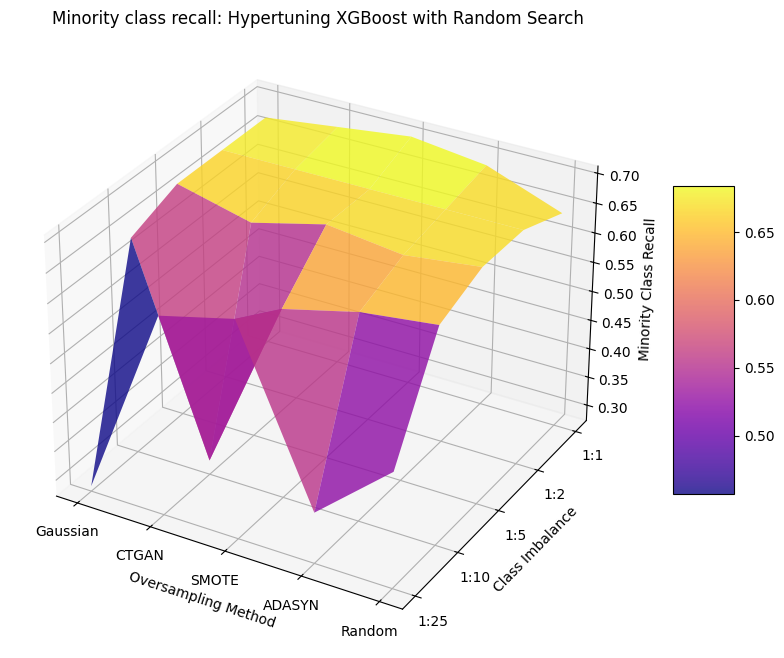

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. Organize the data
data = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=1)

labels = list(data.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings for the X and Y axes
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values (Recall) into a grid
# We transpose or align based on the meshgrid shape
Z = np.array([data[label] for label in labels]).T

# 4. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.8)

# Customize axes
ax.set_xticks(x_indices)
ax.set_xticklabels(labels)
ax.set_yticks(y_indices)
ax.set_yticklabels(y_labels)

ax.set_xlabel('Oversampling Method')
ax.set_ylabel('Class Imbalance')
ax.set_zlabel('Minority Class Recall')
ax.set_title('Minority class recall: Hypertuning XGBoost with Random Search')

# Add a color bar for reference
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

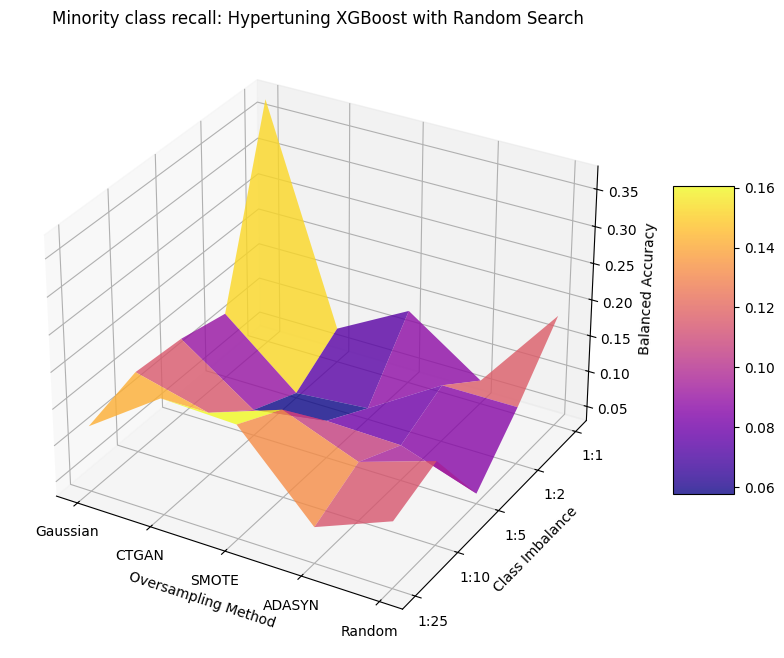

In [47]:
# 1. Organize the data
data = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=2)

labels = list(data.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings for the X and Y axes
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values (Recall) into a grid
# We transpose or align based on the meshgrid shape
Z = np.array([data[label] for label in labels]).T

# 4. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.8)

# Customize axes
ax.set_xticks(x_indices)
ax.set_xticklabels(labels)
ax.set_yticks(y_indices)
ax.set_yticklabels(y_labels)

ax.set_xlabel('Oversampling Method')
ax.set_ylabel('Class Imbalance')
ax.set_zlabel('Balanced Accuracy')
ax.set_title('Minority class recall: Hypertuning XGBoost with Random Search')

# Add a color bar for reference
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

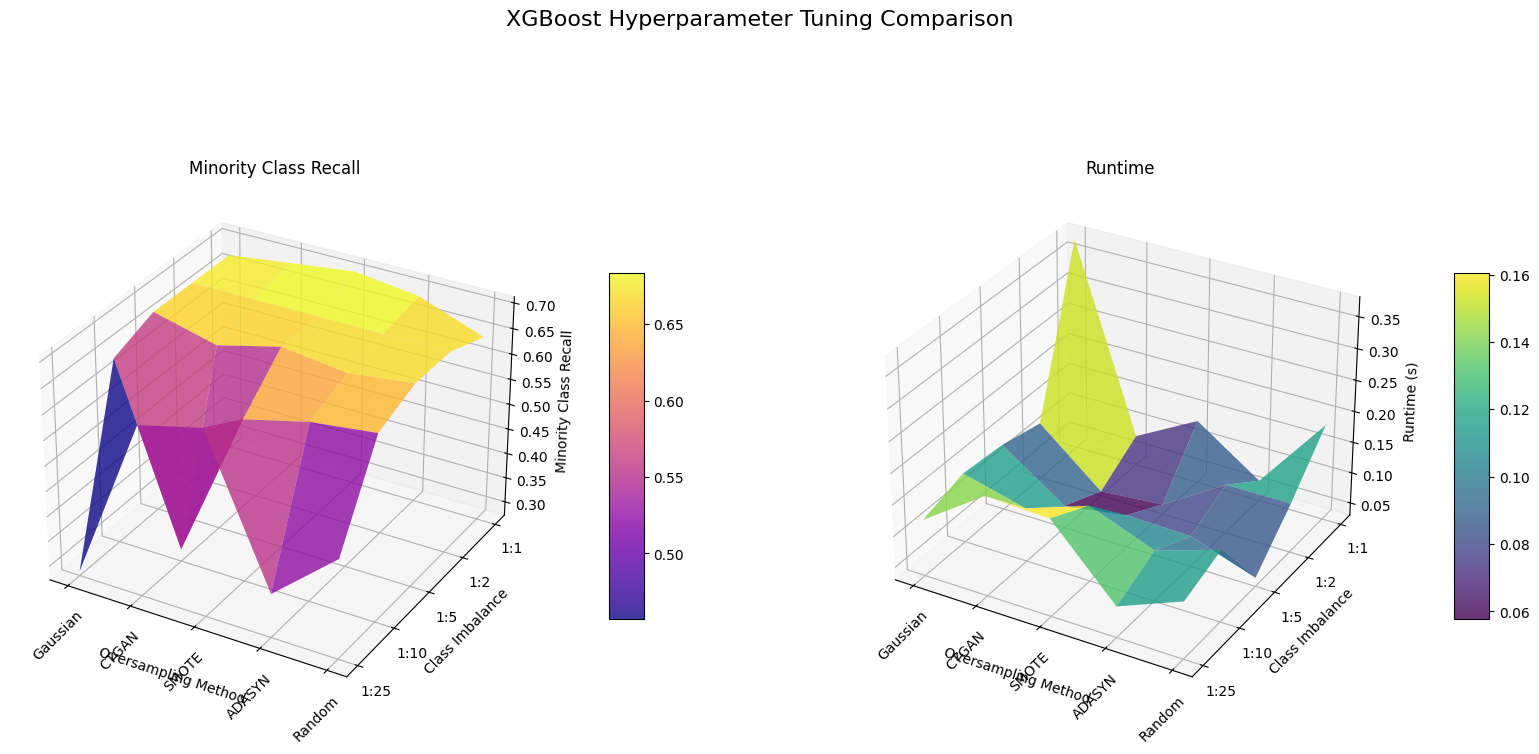

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. Organize the data for both metrics
# Data for Recall (n=1)
data_recall = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=1)

# Data for Balanced Accuracy (n=2)
data_acc = extract_values([
    results_optuna_gaussian,
    results_optuna_ctgan,
    results_optuna_smote,
    results_optuna_adasyn,
    results_optuna_random
], n=2)

labels = list(data_recall.keys())
sizes = [25, 10, 5, 2, 1]

# 2. Create numerical mappings (shared by both)
x_indices = np.arange(len(labels))
y_indices = np.arange(len(sizes))
y_labels = [f'1:{size}' for size in sizes]
X, Y = np.meshgrid(x_indices, y_indices)

# 3. Extract Z values
Z1 = np.array([data_recall[label] for label in labels]).T
Z2 = np.array([data_acc[label] for label in labels]).T

# 4. Plotting in one figure with two subplots
fig = plt.figure(figsize=(20, 9)) # Increased width for two 3D plots

# --- Subplot 1: Minority Class Recall ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z1, cmap='plasma', edgecolor='none', alpha=0.8)

ax1.set_xticks(x_indices)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_yticks(y_indices)
ax1.set_yticklabels(y_labels)

ax1.set_xlabel('Oversampling Method')
ax1.set_ylabel('Class Imbalance')
ax1.set_zlabel('Minority Class Recall')
ax1.set_title('Minority Class Recall')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

# --- Subplot 2: Balanced Accuracy ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z2, cmap='viridis', edgecolor='none', alpha=0.8)

ax2.set_xticks(x_indices)
ax2.set_xticklabels(labels, rotation=45)
ax2.set_yticks(y_indices)
ax2.set_yticklabels(y_labels)

ax2.set_xlabel('Oversampling Method')
ax2.set_ylabel('Class Imbalance')
ax2.set_zlabel('Runtime (s)')
ax2.set_title('Runtime')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

plt.suptitle('XGBoost Hyperparameter Tuning Comparison', fontsize=16)
plt.tight_layout()
plt.show()